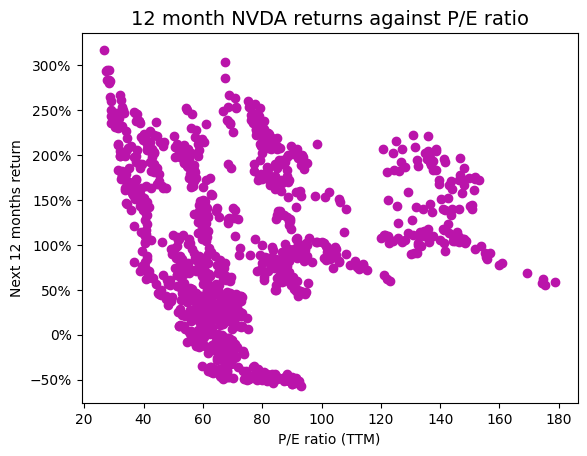

In [3]:
#GENERAL
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker

stock = "NVDA"

eps_hist = yf.Ticker(stock).get_earnings_dates(limit = 8).iloc[::-1, 1].dropna()
ttm_eps = eps_hist.rolling(window = 4, min_periods = 1).sum()
price_hist = yf.Ticker(stock).history(start = eps_hist.index[0], end = eps_hist.index[-1]).loc[:,"Close"].dropna()
df = pd.concat([ttm_eps.rename("EPS (TTM)"), price_hist.rename("Close Price")], axis=1, join = "outer", sort = True).ffill().dropna()
df["P/E ratio (TTM)"] = df["Close Price"]/df["EPS (TTM)"]
df["Next 12 months return"] = df["Close Price"].shift(-252)/df["Close Price"] - 1 #this can certainly be improved using idxmin rather just 252d assumption

fig,ax = plt.subplots()
ax.scatter(df["P/E ratio (TTM)"], df["Next 12 months return"], c = ["#BA14AA"])
ax.set_title(f"12 month {stock} returns against P/E ratio", fontdict = {"fontsize":14})
ax.set_xlabel("P/E ratio (TTM)"), ax.set_ylabel("Next 12 months return");
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax = 1, decimals = 0))

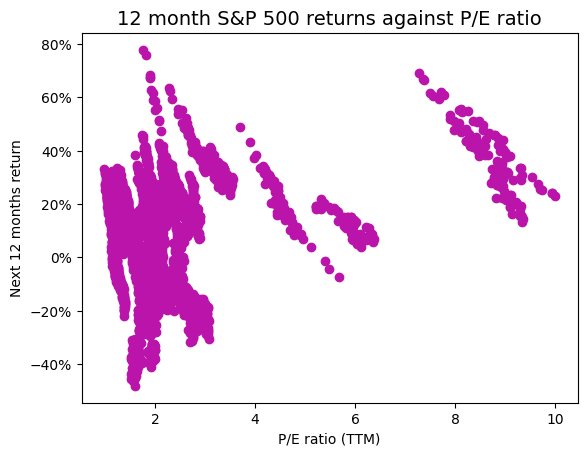

In [2]:
#SPY
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker

ttm_eps = pd.read_excel("C:/Users/ollie/Documents/Academic/Quant/Github/data/s-p-500-earnings-history.xlsx", index_col = 0, names = ["EPS (TTM)"]).dropna()
price_hist = yf.Ticker("SPY").history(start = ttm_eps.index[0], end = ttm_eps.index[-1]).tz_localize(None).loc[:,"Close"].dropna()
df = pd.concat([ttm_eps, price_hist.rename("Close Price")], axis=1, join = "outer", sort = True).ffill().dropna()
df["P/E ratio (TTM)"] = df["Close Price"]/df["EPS (TTM)"]
df["Next 12 months return"] = df["Close Price"].shift(-252)/df["Close Price"] - 1 #this can certainly be improved using idxmin rather just 252d assumption

fig,ax = plt.subplots()
ax.scatter(df["P/E ratio (TTM)"], df["Next 12 months return"], c = ["#BA14AA"])
ax.set_title(f"12 month S&P 500 returns against P/E ratio", fontdict = {"fontsize":14})
ax.set_xlabel("P/E ratio (TTM)"), ax.set_ylabel("Next 12 months return");
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax = 1, decimals = 0))